In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("international_debt.csv")

df.head()

,country_name,country_code,indicator_name,indicator_code,debt
0,Afghanistan,AFG,"Disbursements on external debt, long-term (DIS...",DT.DIS.DLXF.CD,72894453.7
1,Afghanistan,AFG,"Interest payments on external debt, long-term ...",DT.INT.DLXF.CD,53239440.1
2,Afghanistan,AFG,"PPG, bilateral (AMT, current US$)",DT.AMT.BLAT.CD,61739336.9
3,Afghanistan,AFG,"PPG, bilateral (DIS, current US$)",DT.DIS.BLAT.CD,49114729.4
4,Afghanistan,AFG,"PPG, bilateral (INT, current US$)",DT.INT.BLAT.CD,39903620.1


In [3]:
df.shape

(2357, 5)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_name    2357 non-null   object 
 1   country_code    2357 non-null   object 
 2   indicator_name  2357 non-null   object 
 3   indicator_code  2357 non-null   object 
 4   debt            2357 non-null   float64
dtypes: float64(1), object(4)
memory usage: 92.2+ KB


In [5]:
df.describe()

,debt
count,2.357000e+03
mean,1.306633e+09
std,5.226771e+09
min,0.000000e+00
25%,1.548248e+07
50%,1.073140e+08
75%,5.716575e+08
max,9.621862e+10


In [6]:

df.isnull().sum()

country_name      0
country_code      0
indicator_name    0
indicator_code    0
debt              0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df['country_name'].nunique()

124

In [9]:
df['country_name'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Armenia',
       'Azerbaijan', 'Bangladesh', 'Belarus', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia',
       'Cameroon', 'Central African Republic', 'Chad', 'China',
       'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Djibouti', 'Dominica',
       'Dominican Republic', 'Georgia', 'Ecuador', 'Egypt, Arab Rep.',
       'El Salvador', 'Eritrea', 'Eswatini', 'Ethiopia', 'Fiji', 'Gabon',
       'Gambia, The', 'Ghana', 'Grenada', 'Guatemala', 'Guinea',
       'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'IDA only',
       'India', 'Indonesia', 'Iran, Islamic Rep.', 'Jamaica', 'Jordan',
       'Kazakhstan', 'Kenya', 'Kosovo', 'Kyrgyz Republic', 'Lao PDR',
       'Lesotho', 'Least developed countries: UN classification',
       'Lebanon', 'Liberia', 'Macedonia, FYR',

In [10]:
country_debt = df.groupby('country_name')['debt'].sum().sort_values(ascending=False)

country_debt.head(10)

country_name
China                                           2.857935e+11
Brazil                                          2.806240e+11
South Asia                                      2.476087e+11
Least developed countries: UN classification    2.128810e+11
Russian Federation                              1.912891e+11
IDA only                                        1.790481e+11
Turkey                                          1.511258e+11
India                                           1.336271e+11
Mexico                                          1.245968e+11
Indonesia                                       1.134357e+11
Name: debt, dtype: float64

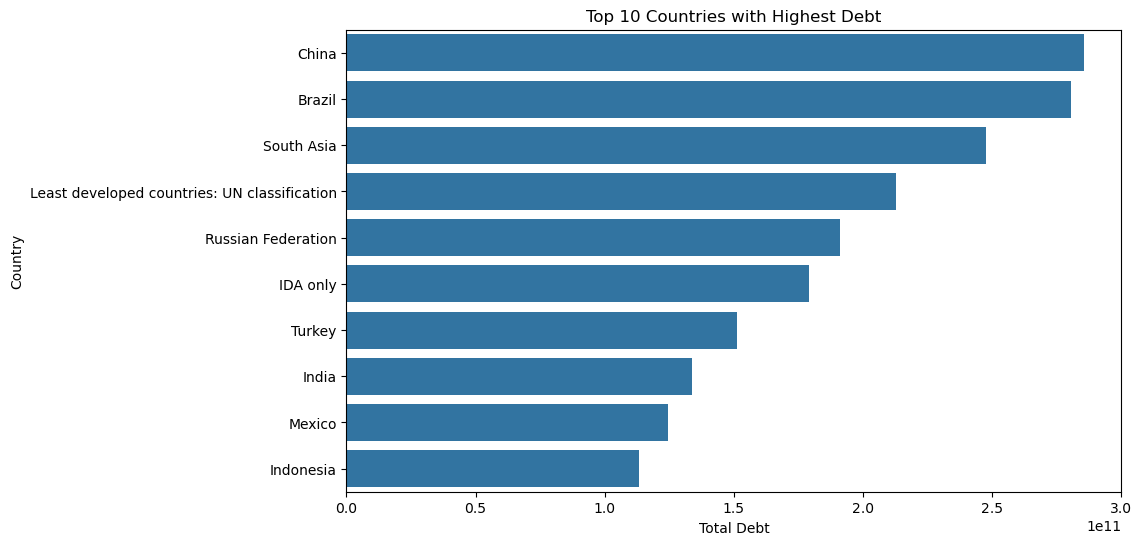

In [11]:
top10 = country_debt.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Countries with Highest Debt")
plt.xlabel("Total Debt")
plt.ylabel("Country")

plt.show()

In [12]:
indicator_debt = df.groupby('indicator_name')['debt'].sum().sort_values(ascending=False)

indicator_debt.head(10)

indicator_name
Principal repayments on external debt, long-term (AMT, current US$)                      7.322037e+11
Principal repayments on external debt, private nonguaranteed (PNG) (AMT, current US$)    4.077344e+11
Disbursements on external debt, long-term (DIS, current US$)                             2.647011e+11
PPG, official creditors (DIS, current US$)                                               2.389960e+11
Interest payments on external debt, long-term (INT, current US$)                         2.038590e+11
PPG, private creditors (AMT, current US$)                                                1.767620e+11
PPG, official creditors (AMT, current US$)                                               1.477073e+11
PPG, bilateral (DIS, current US$)                                                        1.382147e+11
PPG, multilateral (DIS, current US$)                                                     1.007812e+11
Interest payments on external debt, private nonguaranteed (PNG) (IN

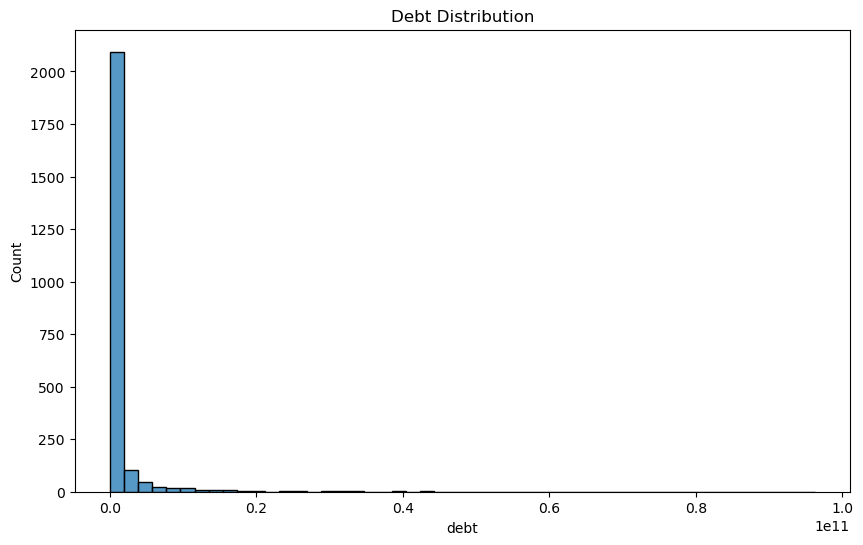

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(df['debt'], bins=50)

plt.title("Debt Distribution")

plt.show()

In [14]:
long_term = df[df['indicator_name'].str.contains("long term", case=False)]

long_term_country = long_term.groupby('country_name')['debt'].sum().sort_values(ascending=False)

long_term_country.head(10)

Series([], Name: debt, dtype: float64)

In [15]:
long_term = df[df['indicator_name'].str.contains("long term", case=False)]

long_term_country = long_term.groupby('country_name')['debt'].sum().sort_values(ascending=False)

long_term_country.head(10)

Series([], Name: debt, dtype: float64)

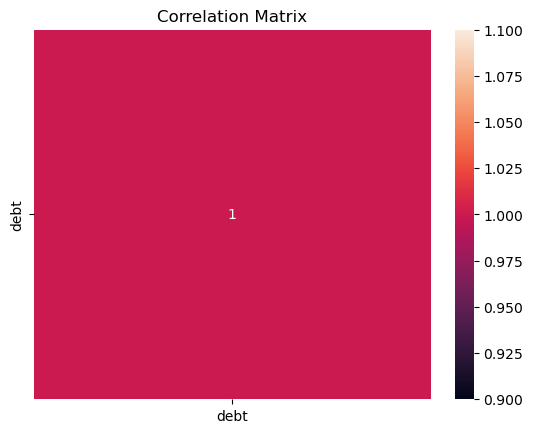

In [16]:
df_numeric = df[['debt']]

corr = df_numeric.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")

plt.show()